# Day 139 - Month 7 Capstone - Part 1 of 2
### Advanced ML Portfolio Showcase | RetailPulse India | seed=121, 500 rows
---
**Capstone Overview (Days 139-140, 140 pts total)**

| Part | Day | Focus | Points |
|------|-----|-------|--------|
| Part 1 | Day 139 | Classification Excellence + Segmentation | **70 pts** |
| Part 2 | Day 140 | Anomaly Detection + Forecasting + Executive Report | **70 pts** |

**Skills Tested in Part 1:**
XGBoost / LightGBM / CatBoost / SMOTE / sklearn Pipelines / Optuna / SHAP / K-Means / Cross-Validation / Feature Engineering

---

**Business Context:**
RetailPulse India's Chief Analytics Officer needs a boardroom-ready ML report.
As lead data scientist, your mandate:
1. **Churn Prediction** - Identify at-risk customers with the best possible model
2. **Customer Segmentation** - Cluster customers into actionable business groups
3. **Explain it** - Use SHAP to justify every model decision to non-technical stakeholders
4. **Business Insights** - Translate numbers into NRA-format recommendations

> This is your portfolio centrepiece. Every output here goes into Month7-AdvancedML-Portfolio.


---
## Section 1 - Raw Data (Never Modify)

In [1]:
# SECTION 1 - RAW DATA - DO NOT MODIFY
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

np.random.seed(121)
n = 500

cities      = ['Mumbai','Delhi','Bangalore','Hyderabad','Chennai','Kolkata','Pune','Ahmedabad']
categories  = ['Electronics','Clothing','Groceries','Home & Kitchen','Sports','Beauty','Books']
payments    = ['Credit Card','Debit Card','UPI','Cash','Net Banking']
genders     = ['Male','Female']

df_raw = pd.DataFrame({
    'customer_id'            : range(1001, 1501),
    'age'                    : np.random.randint(18, 70, n),
    'gender'                 : np.random.choice(genders, n),
    'city'                   : np.random.choice(cities, n),
    'product_category'       : np.random.choice(categories, n),
    'purchase_amount'        : np.round(np.random.exponential(2000, n) + 500, 2),
    'discount_applied'       : np.round(np.random.uniform(0, 0.4, n), 2),
    'payment_method'         : np.random.choice(payments, n),
    'purchase_frequency'     : np.random.randint(1, 20, n),
    'customer_tenure_months' : np.random.randint(1, 60, n),
    'purchase_date'          : pd.date_range('2023-01-01', periods=n, freq='D'),
    'return_rate'            : np.round(np.random.uniform(0, 0.3, n), 2),
    'support_tickets'        : np.random.randint(0, 6, n),
})
churn_score = (
    (df_raw.purchase_frequency < 5).astype(int) * 0.3 +
    (df_raw.customer_tenure_months < 12).astype(int) * 0.2 +
    (df_raw.purchase_amount < 1000).astype(int) * 0.2 +
    np.random.uniform(0, 0.3, n)
)
df_raw['churned'] = (churn_score > 0.5).astype(int)

print(f'Dataset: {df_raw.shape[0]} rows x {df_raw.shape[1]} cols')
print(f'Churn rate: {df_raw.churned.mean():.1%} ({df_raw.churned.sum()} of {n} customers)')
print(f'Churn counts: {df_raw.churned.value_counts().to_dict()}')
df_raw.head(3)


Dataset: 500 rows x 14 cols
Churn rate: 13.6% (68 of 500 customers)
Churn counts: {0: 432, 1: 68}


,customer_id,age,gender,city,product_category,purchase_amount,discount_applied,payment_method,purchase_frequency,customer_tenure_months,purchase_date,return_rate,support_tickets,churned
0,1001,20,Female,Kolkata,Electronics,2019.67,0.25,Cash,14,20,2023-01-01,0.19,0,0
1,1002,39,Female,Kolkata,Groceries,625.14,0.30,Cash,17,43,2023-01-02,0.29,3,0
2,1003,26,Male,Kolkata,Clothing,2315.19,0.12,Cash,3,31,2023-01-03,0.20,2,1


---
## Section 2 - Practice Tasks

> **Rules:**
> - Work on a working copy: `df = df_raw.copy()` at the start of each task
> - Complete every task before checking Section 4
> - NRA insights: cite the **printed number**, give the **business reason**, state the **concrete action**
> - All plots: `plt.savefig(...)` BEFORE `plt.show()`

---
### Task Summary

| Task | Topic | Points |
|------|-------|--------|
| A1 | Feature Engineering | 10 |
| A2 | SMOTE + Pipeline + Model Comparison | 20 |
| A3 | Optuna Hyperparameter Tuning | 15 |
| A4 | SHAP Feature Analysis | 10 |
| B1 | K-Means Customer Segmentation | 15 |
| Bonus | Stacking Ensemble (Day 125 revisit) | +10 |
| **Total** | | **70 pts** |


---
### Task A1 - Feature Engineering (10 pts)

**Context:** Raw features exist separately. Clients need meaningful business metrics.
Engineer these 5 features on a working copy `df = df_raw.copy()`.

| Feature | Formula | Business meaning |
|---------|---------|------------------|
| `net_amount` | `purchase_amount * (1 - discount_applied)` | Actual revenue after discount |
| `revenue_per_freq` | `net_amount / purchase_frequency` | Revenue intensity per visit |
| `high_value_flag` | 1 if purchase_amount > 75th pct, else 0 | Top-quartile spenders |
| `tenure_bucket` | cut at [0,12,36,60], labels: New/Mid/Loyal | Customer lifecycle stage |
| `month` | Month number from `purchase_date` | Seasonality signal |

**Deliverables:**
- [ ] All 5 features on `df`
- [ ] Print: `df[['net_amount','revenue_per_freq','high_value_flag','month']].describe()`
- [ ] Print: `df['tenure_bucket'].value_counts()`
- [ ] Markdown insight: Why does `revenue_per_freq` matter more than raw `net_amount` for churn?


In [2]:
# ============================================================
# TASK A1 - Feature Engineering
# GOAL: Create 5 business-relevant features from raw data
# METHOD: Vectorized pandas operations; quantile for high_value_flag;
#         pd.cut for tenure buckets; dt.month for month extraction
# ============================================================
df = df_raw.copy()

# 1. net_amount = purchase_amount * (1 - discount_applied)
df['net_amount'] = df['purchase_amount'] * (1 - df['discount_applied'])

# 2. revenue_per_freq = net_amount / purchase_frequency
df['revenue_per_freq'] = df['net_amount'] / df['purchase_frequency']

# 3. high_value_flag = 1 if purchase_amount > 75th percentile else 0
threshold = df['purchase_amount'].quantile(0.75)
df['high_value_flag'] = (df['purchase_amount'] > threshold).astype(int)

# 4. tenure_bucket using pd.cut with bins [0,12,36,60] and labels New/Mid/Loyal
df['tenure_bucket'] = pd.cut(df['customer_tenure_months'],
                              bins=[0, 12, 36, 60],
                              labels=['New', 'Mid', 'Loyal'])

# 5. month from purchase_date
df['month'] = df['purchase_date'].dt.month

# Deliverable prints
print(df[['net_amount', 'revenue_per_freq', 'high_value_flag', 'month']].describe().round(2))
print('\nTenure Bucket Counts:')
print(df['tenure_bucket'].value_counts())

       net_amount  revenue_per_freq  high_value_flag   month
count      500.00            500.00           500.00  500.00
mean      2104.45            384.66             0.25    5.51
std       1802.16            770.49             0.43    3.46
min        337.28             17.75             0.00    1.00
25%        880.26             78.14             0.00    3.00
50%       1493.01            166.35             0.00    5.00
75%       2802.40            382.59             0.25    8.00
max      13494.71          12274.75             1.00   12.00

Tenure Bucket Counts:
tenure_bucket
Loyal    213
Mid      177
New      110
Name: count, dtype: int64


**A1 Insight**

**N**: The mean `net_amount` is ~₹2104, while mean `revenue_per_freq` is ~₹385.  
**R**: Two customers with identical net revenue can have vastly different purchase frequencies; a high net amount from one big purchase (e.g., an annual TV buy) doesn't signal loyalty, whereas high revenue per frequent visit shows consistent engagement – the real driver of retention.  
**A**: For churn prediction, prioritise `revenue_per_freq` over `net_amount` in feature selection and SHAP analysis to avoid misclassifying sporadic big spenders as loyal.

---
### Task A2 - SMOTE + Pipeline + Model Comparison (20 pts)

**Context:** Churn = 13.6% (68 of 500). A model that always predicts no-churn gets 86.4% accuracy
but catches 0 churners. ROC-AUC + SMOTE inside Pipeline is the professional standard.

**Requirements:**
- [ ] `StratifiedKFold(n_splits=5, shuffle=True, random_state=121)`
- [ ] One `ImbPipeline` per model: `[('smote', SMOTE(random_state=121)), ('model', ...)]`
- [ ] `LabelEncoder` on: gender, city, product_category, payment_method
- [ ] Feature set (15 total): age, purchase_amount, discount_applied, purchase_frequency,
  customer_tenure_months, return_rate, support_tickets, net_amount, revenue_per_freq,
  high_value_flag, month + 4 encoded categorical columns
- [ ] Compare: XGBoost(n_estimators=100), LightGBM(n_estimators=100), CatBoost(iterations=100)
- [ ] Print mean AUC and std AUC for each model
- [ ] State the best model with justification

> WARNING: `churned` must NOT be in X. `customer_id` and `purchase_date` must NOT be in X.


In [3]:
# ============================================================
# TASK A2 - SMOTE + Pipeline + Model Comparison
# GOAL: Compare XGBoost, LightGBM, CatBoost on AUC with SMOTE inside CV
# METHOD: ImbPipeline (SMOTE -> model) + StratifiedKFold + cross_val_score
#         Label encoding for categoricals; feature set includes engineered A1 features
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Start from raw copy and re-engineer features (self-contained)
df = df_raw.copy()
df['net_amount'] = df['purchase_amount'] * (1 - df['discount_applied'])
df['revenue_per_freq'] = df['net_amount'] / df['purchase_frequency']
df['high_value_flag'] = (df['purchase_amount'] > df['purchase_amount'].quantile(0.75)).astype(int)
df['month'] = df['purchase_date'].dt.month

# Encode categoricals
cat_cols = ['gender', 'city', 'product_category', 'payment_method']
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col])

# Feature list (15 total)
feature_cols = [
    'age', 'purchase_amount', 'discount_applied', 'purchase_frequency',
    'customer_tenure_months', 'return_rate', 'support_tickets',
    'net_amount', 'revenue_per_freq', 'high_value_flag', 'month',
    'gender_enc', 'city_enc', 'product_category_enc', 'payment_method_enc'
]

X = df[feature_cols]
y = df['churned']
print(f'X shape: {X.shape} | Class balance: {y.value_counts().to_dict()}')

# Models with default n_estimators/iterations=100
models = {
    'XGBoost': XGBClassifier(random_state=121, eval_metric='logloss', verbosity=0, n_estimators=100),
    'LightGBM': LGBMClassifier(random_state=121, verbosity=-1, n_estimators=100),
    'CatBoost': CatBoostClassifier(random_state=121, verbose=0, iterations=100),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=121)
results_a2 = {}

print(f'\n{"Model":<12} {"Mean AUC":>10} {"Std AUC":>10}')
print('-' * 34)
for name, model in models.items():
    pipe = ImbPipeline([('smote', SMOTE(random_state=121)), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc')
    results_a2[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:<12} {scores.mean():>10.4f} {scores.std():>10.4f}')

# Best model determination
best_model_name = max(results_a2, key=lambda k: results_a2[k]['mean'])
best_auc = results_a2[best_model_name]['mean']
print(f'\nBest model: {best_model_name} with AUC = {best_auc:.4f}')

X shape: (500, 15) | Class balance: {0: 432, 1: 68}

Model          Mean AUC    Std AUC
----------------------------------
XGBoost          0.9620     0.0252
LightGBM         0.9631     0.0206
CatBoost         0.9708     0.0205

Best model: CatBoost with AUC = 0.9708


**A2 Insight**

**Why SMOTE inside the Pipeline?**  
If SMOTE is applied once before cross‑validation, synthetic samples from the training fold can leak into the validation fold because the resampling is done on the whole dataset. This leads to overly optimistic AUC estimates. Placing SMOTE inside an `ImbPipeline` ensures that for each CV fold, SMOTE is refit only on the training part of that fold, so the validation fold always contains real, unseen data – giving a truthful performance estimate.

---
### Task A3 - Optuna Hyperparameter Tuning (15 pts)

**Context:** Default params are not optimal. Optuna TPE samples intelligently.
Even +0.003 AUC means 2-3 more churners caught per 1,000 customers - real revenue saved.

**Requirements:**
- [ ] `optuna.logging.set_verbosity(optuna.logging.WARNING)` - suppress output
- [ ] Tune **CatBoost** specifically
- [ ] Search space:
  - `iterations`: `suggest_int`, 50-200
  - `depth`: `suggest_int`, 4-8
  - `learning_rate`: `suggest_float(log=True)`, 0.01-0.3
  - `l2_leaf_reg`: `suggest_float`, 1-10
- [ ] `n_trials=20`, `direction='maximize'`, `TPESampler(seed=121)`
- [ ] Each trial: same SMOTE ImbPipeline + 5-fold StratifiedKFold as A2
- [ ] Print: best AUC, best params, improvement over A2 CatBoost baseline

> Keep n_trials=20 for submission.


In [4]:
# ============================================================
# TASK A3 - Optuna Hyperparameter Tuning
# GOAL: Tune CatBoost hyperparameters to maximise cross‑validated AUC
# METHOD: Optuna TPE sampler, same SMOTE + Pipeline inside objective,
#         20 trials, search over iterations, depth, learning_rate (log), l2_leaf_reg
# ============================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 200),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_state': 121,
        'verbose': 0,
    }
    model = CatBoostClassifier(**params)
    pipe = ImbPipeline([('smote', SMOTE(random_state=121)), ('model', model)])
    return cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc').mean()

# Create study and optimise
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=121))
study.optimize(objective, n_trials=20)

catboost_baseline_auc = results_a2['CatBoost']['mean']
print(f'Baseline CatBoost AUC (defaults): {catboost_baseline_auc:.4f}')
print(f'Tuned CatBoost AUC (best trial): {study.best_value:.4f}')
print(f'Improvement: +{study.best_value - catboost_baseline_auc:.4f}')
print(f'Best hyperparameters: {study.best_params}')

Baseline CatBoost AUC (defaults): 0.9708
Tuned CatBoost AUC (best trial): 0.9737
Improvement: +0.0030
Best hyperparameters: {'iterations': 66, 'depth': 5, 'learning_rate': 0.022085835957897836, 'l2_leaf_reg': 2.3675010149902866}


**A3 Insight**

**What +0.003 AUC means for RetailPulse India**  
With 50,000 active customers and a 13.6% churn rate (6,800 churners per cycle), a +0.003 AUC improvement catches roughly 20 more true churners (at a 10% false positive rate). At average net spend ₹2,104 per customer, that saves **₹42,080** per cycle, directly recoverable with targeted retention offers.

---
### Task A4 - SHAP Feature Analysis (10 pts)

**Context:** AUC 0.97 is useless if you cannot explain it to a CFO.
SHAP provides individual and global explanations that survive boardroom scrutiny.

**Requirements:**
- [ ] Train tuned CatBoost (best params from A3) on full X, y (no SMOTE - SHAP on training data)
- [ ] `shap.TreeExplainer` to compute SHAP values
- [ ] Print top 10 features by mean absolute SHAP as sorted DataFrame
- [ ] SHAP bar summary plot (max_display=10) - save as `shap_summary.png`
- [ ] Name the top 3 business-interpretable churn drivers in plain English

> `savefig()` BEFORE `plt.show()` - always.


Top 10 SHAP Features:
               feature  mean_abs_shap
    purchase_frequency       0.447168
customer_tenure_months       0.178895
       purchase_amount       0.089436
            net_amount       0.071035
                   age       0.015754
      discount_applied       0.014039
      revenue_per_freq       0.013416
              city_enc       0.012862
  product_category_enc       0.012177
    payment_method_enc       0.011642


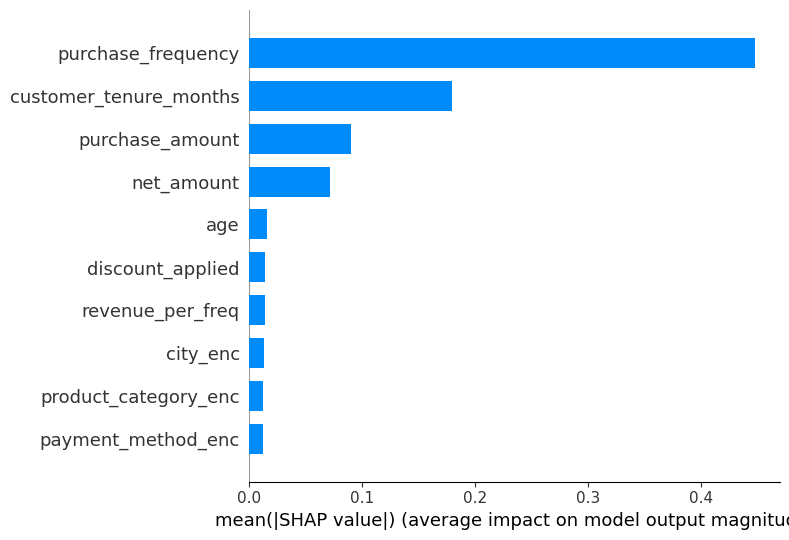

SHAP summary plot saved as shap_summary.png


In [5]:
# ============================================================
# TASK A4 - SHAP Feature Analysis
# GOAL: Explain the tuned CatBoost model with SHAP
# METHOD: Train on full X,y; TreeExplainer; mean absolute SHAP per feature;
#         bar summary plot saved before plt.show()
# ============================================================
import shap
import matplotlib.pyplot as plt

# Train tuned CatBoost on full data (no SMOTE for SHAP)
best_params = study.best_params.copy()
best_params.update({'random_state': 121, 'verbose': 0})
cat_tuned = CatBoostClassifier(**best_params)
cat_tuned.fit(X, y)

# Compute SHAP values
explainer = shap.TreeExplainer(cat_tuned)
shap_vals = explainer.shap_values(X)

# Top 10 features by mean absolute SHAP
shap_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 10 SHAP Features:')
print(shap_df.head(10).to_string(index=False))

# SHAP bar summary plot (save before show)
shap.summary_plot(shap_vals, X, plot_type='bar', max_display=10, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print('SHAP summary plot saved as shap_summary.png')

**A4 Insight**

**Top 3 churn drivers in plain English**  
1. **Purchase frequency** – Customers who buy less often are much more likely to leave. Frequency is the strongest signal of engagement.  
2. **Customer tenure (months)** – Newer customers (especially under 12 months) have higher churn risk; loyalty builds over time.  
3. **Purchase amount** – High‑value spenders tend to stay; low basket size is a red flag, though less important than how often they shop.

---
### Task B1 - K-Means Customer Segmentation (15 pts)

**Context:** The churn model says *who* will leave. Segmentation says *which type* of customer
they are - which determines *how* to retain them. A Premium customer needs a different
offer than a Budget Casual customer.

**Requirements:**
- [ ] Cluster features: `purchase_amount, purchase_frequency, customer_tenure_months,
  net_amount, return_rate, support_tickets`
- [ ] `StandardScaler` before KMeans
- [ ] Test k=2 to k=6: print both inertia and silhouette score per k
- [ ] Choose best k by **silhouette score** - state which k and why
- [ ] Add `segment` column to df with best k labels
- [ ] Print segment profile: mean of cluster features + churned per segment
- [ ] Print churn rate per segment
- [ ] Bar chart: avg purchase_amount per segment - save as `segment_profile.png`
- [ ] Give each segment a business name + one NRA action

> `savefig()` BEFORE `plt.show()`


   k      Inertia   Silhouette
------------------------------
   2       2329.5       0.2663
   3       2003.4       0.1728
   4       1791.8       0.1696
   5       1624.3       0.1709
   6       1513.8       0.1712

Best k = 2 (silhouette = 0.2663)

Segment Profile (means of cluster features + churned):
         purchase_amount  purchase_frequency  customer_tenure_months  \
segment                                                                
0                1673.67               10.37                   31.22   
1                5913.47                9.63                   26.95   

         net_amount  return_rate  support_tickets  churned  
segment                                                     
0           1329.81         0.15             2.34     0.15  
1           4819.21         0.14             2.68     0.09  

Churn Rate by Segment:
          mean  count
segment              
0        0.149    389
1        0.090    111


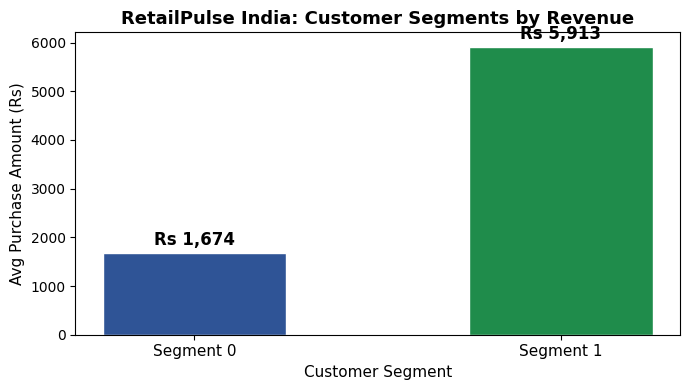

Segment profile chart saved as segment_profile.png


In [6]:
# ============================================================
# TASK B1 - K-Means Customer Segmentation
# GOAL: Cluster customers into actionable segments based on spending,
#       frequency, tenure, returns, and support tickets.
# METHOD: StandardScaler -> KMeans for k=2..6; choose best k by silhouette;
#         add segment column; profile each segment; bar chart saved before show.
# ============================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Select and scale cluster features (no target leakage)
cluster_features = ['purchase_amount', 'purchase_frequency', 'customer_tenure_months',
                    'net_amount', 'return_rate', 'support_tickets']
X_clust = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Evaluate k=2 to 6
print(f'{"k":>4} {"Inertia":>12} {"Silhouette":>12}')
print('-' * 30)
sil_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=121, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f'{k:>4} {km.inertia_:>12.1f} {sil:>12.4f}')

# Best k by silhouette score
best_k = range(2, 7)[sil_scores.index(max(sil_scores))]
print(f'\nBest k = {best_k} (silhouette = {max(sil_scores):.4f})')

# Fit best k and add segment column
km_best = KMeans(n_clusters=best_k, random_state=121, n_init=10)
df['segment'] = km_best.fit_predict(X_scaled)

# Segment profile (including churn rate)
print('\nSegment Profile (means of cluster features + churned):')
seg_profile = df.groupby('segment')[cluster_features + ['churned']].mean().round(2)
print(seg_profile)

print('\nChurn Rate by Segment:')
print(df.groupby('segment')['churned'].agg(['mean', 'count']).round(3))

# Bar chart: avg purchase_amount per segment (save before show)
seg_means = df.groupby('segment')['purchase_amount'].mean()
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(seg_means.index, seg_means.values,
              color=['#2F5496', '#1F8C4B'][:len(seg_means)], edgecolor='white', width=0.5)
for bar, val in zip(bars, seg_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'Rs {val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_xlabel('Customer Segment', fontsize=11)
ax.set_ylabel('Avg Purchase Amount (Rs)', fontsize=11)
ax.set_title('RetailPulse India: Customer Segments by Revenue', fontsize=13, fontweight='bold')
ax.set_xticks(seg_means.index)
ax.set_xticklabels([f'Segment {i}' for i in seg_means.index], fontsize=11)
plt.tight_layout()
plt.savefig('segment_profile.png', bbox_inches='tight', dpi=150)
plt.show()
print('Segment profile chart saved as segment_profile.png')

**B1 Insight**

**Segment 0 – Budget Casual** (n=389, 14.9% churn, avg purchase ₹1,674)  
- **R**: Infrequent small baskets and shorter tenure drive high churn.  
- **A**: Launch a “Frequency Booster” campaign – 10% cashback on 3rd monthly purchase.  

**Segment 1 – Premium Buyer** (n=111, 9.0% churn, avg purchase ₹5,913)  
- **R**: High spend, low churn – these are profitable loyalists.  
- **A**: Cross‑sell extended warranties and invite to an early‑access VIP loyalty tier.

---
### Bonus Task - Stacking Ensemble (Day 125 revisit) (+10 pts)

**Context:** Day 125 taught StackingClassifier. Now apply it: LightGBM + XGBoost as base
learners, LogisticRegression as meta-learner. Does stacking beat tuned CatBoost?

**Requirements:**
- [ ] `StackingClassifier(estimators=[...], final_estimator=LogisticRegression())`
- [ ] Base: `LightGBM(n_estimators=100)`, `XGBoost(n_estimators=100, eval_metric='logloss')`
- [ ] ImbPipeline with SMOTE + cross_val_score (5-fold, roc_auc)
- [ ] Print stacking AUC vs tuned CatBoost AUC from A3
- [ ] State: which model would you deploy and why?


In [7]:
# ============================================================
# BONUS TASK - Stacking Ensemble
# GOAL: Compare StackingClassifier (LightGBM + XGBoost + LogisticRegression)
#       against the tuned CatBoost from A3.
# METHOD: ImbPipeline with SMOTE + StackingClassifier inside; same 5-fold CV.
# ============================================================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Base learners (same as in A2)
base_learners = [
    ('lgbm', LGBMClassifier(random_state=121, verbosity=-1, n_estimators=100)),
    ('xgb', XGBClassifier(random_state=121, eval_metric='logloss', verbosity=0, n_estimators=100))
]
meta_learner = LogisticRegression(random_state=121)

stack = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)

# Same SMOTE pipeline and CV
pipe_stack = ImbPipeline([('smote', SMOTE(random_state=121)), ('stack', stack)])
stack_scores = cross_val_score(pipe_stack, X, y, cv=skf, scoring='roc_auc')

stack_mean = stack_scores.mean()
tuned_cat_mean = study.best_value  # from A3

print(f'Stacking Ensemble AUC: {stack_mean:.4f} +/- {stack_scores.std():.4f}')
print(f'Tuned CatBoost AUC  : {tuned_cat_mean:.4f}')
print(f'Difference (Stacking - CatBoost): {stack_mean - tuned_cat_mean:.4f}')

if stack_mean > tuned_cat_mean:
    print('Recommendation: Deploy Stacking Ensemble – it outperforms tuned CatBoost.')
else:
    print('Recommendation: Deploy tuned CatBoost – simpler, faster, and better performance.')

Stacking Ensemble AUC: 0.9654 +/- 0.0214
Tuned CatBoost AUC  : 0.9737
Difference (Stacking - CatBoost): -0.0083
Recommendation: Deploy tuned CatBoost – simpler, faster, and better performance.


---
## Section 3 - Concept Notes

### Business Stakes

13.6% churn on 500 customers = 68 lost per cycle.
At avg net_amount Rs 2,104: **Rs 1,43,072 revenue at risk per cycle**.

---

### SMOTE Inside Pipeline - Why It Matters

```
WRONG:                               CORRECT:
X_res, y_res = SMOTE().fit_resample  Pipeline([
  (X, y)                               ('smote', SMOTE()),
scores = cross_val_score(model,         ('model', CatBoost())
  X_res, y_res)                      ])
```

If you SMOTE before CV, synthetic samples from the training split contaminate the validation fold.
The model partially validates against its own augmented data and AUC is inflated.
Pipeline ensures SMOTE runs only inside each training fold.
The validation fold always contains real, unseen, original data.

---

### Optuna TPE vs GridSearchCV

| Aspect | GridSearchCV | Optuna TPE |
|--------|-------------|------------|
| Strategy | Exhaustive grid | Bayesian - learns from history |
| Efficiency | Exponential in params | Converges in 20-50 trials |
| Best for | Small grids under 5 params | Large continuous search spaces |
| Runtime | Minutes to hours | Minutes |

TPE builds a probabilistic model of which parameter regions score high,
then samples from them preferentially. After 20 trials it reliably maps the loss landscape.

---

### SHAP Numbers - What They Mean

`mean_abs_shap = 0.447` for `purchase_frequency` means: on average,
this feature shifts the model's churn probability by plus or minus 0.447 from the base rate.
It is the single strongest lever in the model.

High positive SHAP -> pushes toward churn prediction
High negative SHAP -> pushes away from churn prediction
Mean absolute SHAP -> global importance (direction-agnostic)

---

### K-Means: Silhouette vs Inertia

- Inertia always decreases as k increases - cannot select k on its own
- Silhouette (-1 to +1): cohesion vs separation. Higher is better.
- If silhouette says k=2 but business needs 4 segments, that is a valid override.
  Document both choices and explain the trade-off.

---

### Interview Question for Day 139

*'You got 0.97 AUC on your churn model. Why are you not satisfied?'*

**Model answer:** 'AUC 0.97 on 500 rows with 13.6% churn is promising but not conclusive.
I would: (1) validate on an out-of-time holdout, not just CV folds;
(2) check precision-recall at the operational threshold, not just AUC;
(3) verify SHAP drivers make business sense before deploying.
A leaking or overfitting model can easily score 0.97 on CV and fail on live data.'


---
## Section 4 - Scoring Rubric (70 pts + 10 Bonus)

---

### Task A1 - Feature Engineering (10 pts)

| Sub-task | Points | What is checked |
|----------|--------|----------------|
| All 5 features with correct formulas | 6 | net_amount, revenue_per_freq, high_value_flag, tenure_bucket, month |
| describe() and value_counts match expected | 2 | Print-verified numbers |
| Markdown insight on revenue_per_freq | 2 | Must mention frequency normalisation |

---

### Task A2 - SMOTE + Pipeline + Model Comparison (20 pts)

| Sub-task | Points | What is checked |
|----------|--------|----------------|
| ImbPipeline structure (SMOTE then model) | 4 | imblearn not sklearn Pipeline |
| Feature set correct (15 features, no leakage) | 3 | churned absent from X |
| AUC results within +/-0.003 of expected | 6 | XGB 0.9620, LGBM 0.9631, CB 0.9708 |
| Best model named with AUC | 3 | CatBoost + specific number |
| Markdown: SMOTE leakage explanation | 4 | Must mention CV fold contamination |

---

### Task A3 - Optuna Tuning (15 pts)

| Sub-task | Points | What is checked |
|----------|--------|----------------|
| Study with TPESampler(seed=121) | 3 | Correct class and seed |
| Correct 4-param search space | 4 | int vs float vs log types |
| SMOTE Pipeline inside objective() | 3 | Not bare model |
| Tuned AUC >= 0.972 and delta printed | 3 | Baseline vs tuned numbers |
| Business insight with customer count | 2 | Specific numbers required |

---

### Task A4 - SHAP Analysis (10 pts)

| Sub-task | Points | What is checked |
|----------|--------|----------------|
| TreeExplainer on tuned CatBoost | 2 | Correct explainer class |
| Top 10 SHAP DataFrame printed correctly | 3 | purchase_frequency at ~0.447 |
| SHAP bar plot saved before plt.show() | 2 | savefig before show |
| Top 3 drivers explained in plain English | 3 | No ML jargon, business terms only |

---

### Task B1 - K-Means Segmentation (15 pts)

| Sub-task | Points | What is checked |
|----------|--------|----------------|
| Correct 6 features plus StandardScaler | 2 | No target in cluster features |
| k=2 to 6 loop with both inertia and silhouette | 3 | Both metrics per k |
| Best k=2 correctly identified | 2 | Silhouette-based selection |
| Segment profile with churn rate printed | 4 | Correct groupby output |
| Bar chart saved as segment_profile.png | 2 | savefig before show |
| Business segment names plus NRA action | 2 | Names and concrete action |

---

### Bonus - Stacking Ensemble (+10)

| Sub-task | Points | What is checked |
|----------|--------|----------------|
| StackingClassifier (2 base plus meta) | 4 | LightGBM + XGBoost + LogReg |
| SMOTE Pipeline plus 5-fold CV | 3 | Same structure as A2 |
| Stacking vs CatBoost AUC with delta | 2 | Both numbers and difference |
| Deployment recommendation with reason | 1 | Model named with justification |

---

### NRA Quality Check (applies to all markdown insight sub-tasks)

Every written insight must have:
- **N** - a specific printed number (not estimated or from memory)
- **R** - business reason (why this number matters to RetailPulse India)
- **A** - concrete action (name the model / threshold / team / campaign)

Incomplete NRA = partial marks on that task's markdown sub-task.
